<a href="https://colab.research.google.com/github/Saurabh312Kumar/ML-Concepts/blob/main/Decison_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import plot_tree

In [200]:
df=pd.read_csv('heart.csv')

In [201]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [202]:
df.shape

(918, 12)

In [203]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [205]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [206]:
df.duplicated().any()

np.False_

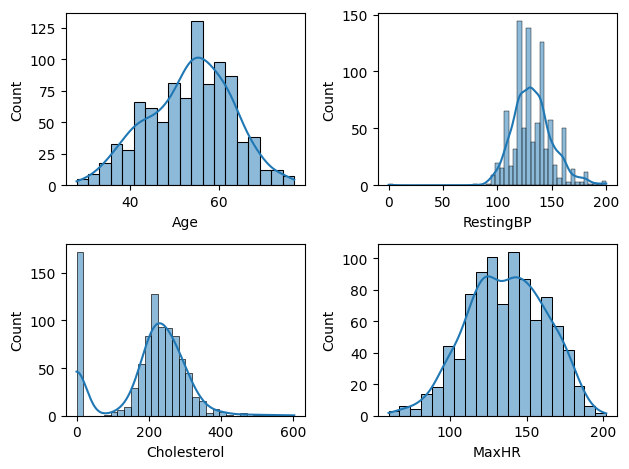

In [207]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)

plt.tight_layout()

In [208]:
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [209]:
cholesterol_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
df['Cholesterol']=df['Cholesterol'].replace(0,cholesterol_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

In [210]:
resting_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df["RestingBP"]=df['RestingBP'].replace(0,resting_mean)
df['RestingBP']=df['RestingBP'].round(2)

In [211]:
print(df['ST_Slope'].unique())
print(df['RestingECG'].unique())
print(df['ChestPainType'].unique())

['Up' 'Flat' 'Down']
['Normal' 'ST' 'LVH']
['ATA' 'NAP' 'ASY' 'TA']


In [212]:
categorical_columns=['Sex','ChestPainType','RestingECG','ST_Slope','ExerciseAngina']

In [213]:
df=pd.get_dummies(df,categorical_columns,drop_first=True)

In [214]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Y,ExerciseAngina_Flat,ExerciseAngina_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [215]:
df=df.astype(float)

<Axes: >

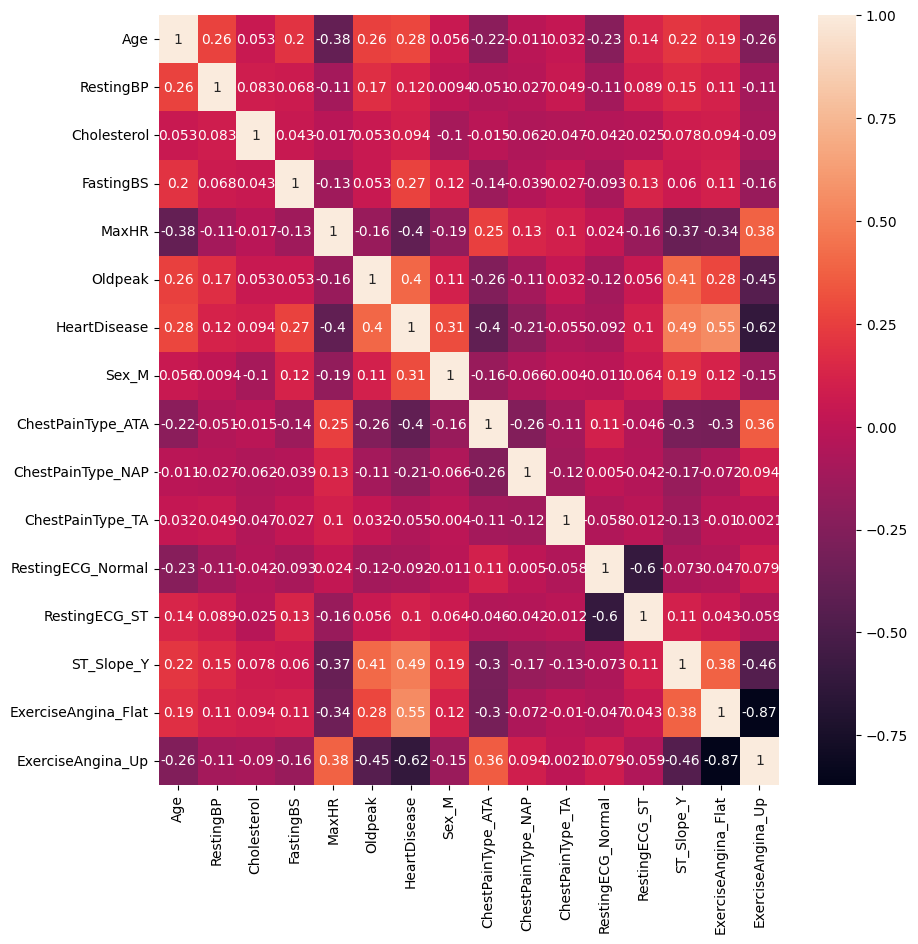

In [216]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [217]:
X=df.drop(columns=['HeartDisease'],axis=1)
y=df['HeartDisease']

In [218]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [219]:
Dt_model=DecisionTreeClassifier()
Dt_model.fit(X_train,y_train)

DecisionTreeClassifier()

In [220]:
y_pred=Dt_model.predict(X_test)

In [222]:
accuracy=accuracy_score(y_test,y_pred)
conf_matrix=confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
print(accuracy)
print(conf_matrix)
print(class_report)

0.8043478260869565
[[63 14]
 [22 85]]
              precision    recall  f1-score   support

         0.0       0.74      0.82      0.78        77
         1.0       0.86      0.79      0.83       107

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.81       184



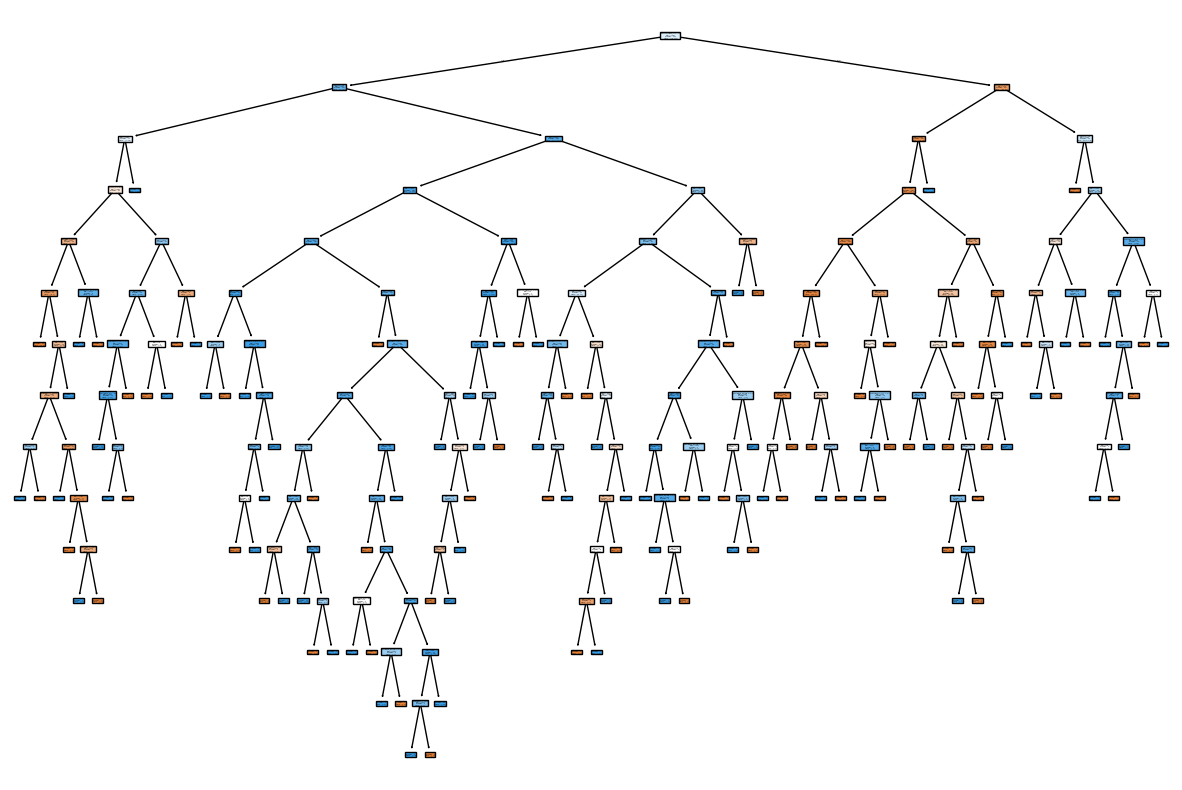

In [231]:
tree_clf=Dt_model
plt.figure(figsize=(15,10))
plot_tree(tree_clf,filled=True,feature_names=X.columns)
plt.show()

In [232]:
param_grid={
    'criterion':['gini','entropy'],
    'max_depth':range(1,10,1),
    'min_samples_split':range(2,10,1),
    'min_samples_leaf':range(1,10,1)
}

In [233]:
dt=DecisionTreeClassifier()

In [234]:
grid_search=GridSearchCV(estimator=dt,param_grid=param_grid,cv=5,verbose=True)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10)},
             verbose=True)

In [235]:
model=grid_search.best_estimator_
y_pred=model.predict(X_test)

In [237]:
accuracy=accuracy_score(y_test,y_pred)
conf_matrix=confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
print(accuracy)
print(conf_matrix)
print(class_report)

0.8206521739130435
[[66 11]
 [22 85]]
              precision    recall  f1-score   support

         0.0       0.75      0.86      0.80        77
         1.0       0.89      0.79      0.84       107

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184



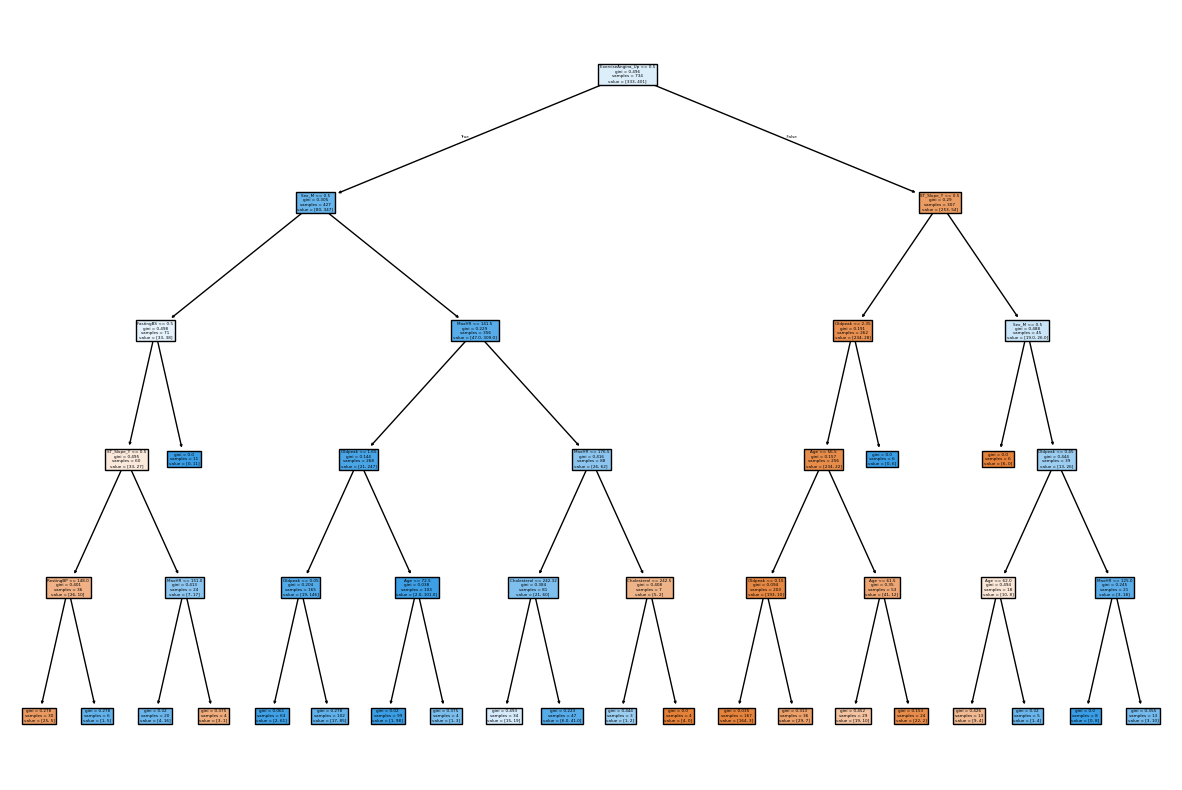

In [238]:
plt.figure(figsize=(15,10))
plot_tree(model,filled=True,feature_names=X.columns)
plt.show()